# Budget Perturbation Walkthrough

Notebook 01 showed the problem: when TV and Meta spend are correlated, OLS elasticity estimates are unreliable. The same market with the same true elasticities gives wildly different answers depending on which period of data you happened to use.

This notebook shows the fix: **deliberately vary the TV/Meta budget split independently of demand**. By introducing independent variation between channels, you give OLS the information it needs to tell them apart.

`BudgetPerturber` quantifies how much independent variation you need to add, and recommends a concrete perturbation level in £ terms.


In [1]:
# config
FAST_MODE = False  # set False for publication-quality runs


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from how_wrong_is_your_mmm import CollinearityDiagnostic, BudgetPerturber, simulate_spend


## The starting point

We start with spend data at correlation 0.7 — typical for two channels following the same campaign calendar. First, we run `CollinearityDiagnostic` to establish the baseline unreliability. This is the number we're trying to reduce.


In [3]:
# generate spend at correlation 0.7
spend = simulate_spend(n_obs=104, correlation=0.7, seed=0)
print(f"Actual TV/Meta correlation: {spend['tv'].corr(spend['meta']):.2f}")
print(f"Mean weekly TV:   £{spend['tv'].mean():,.0f}")
print(f"Mean weekly Meta: £{spend['meta'].mean():,.0f}")
print(f"Mean weekly total: £{(spend['tv'] + spend['meta']).mean():,.0f}")


Actual TV/Meta correlation: 0.63
Mean weekly TV:   £100,568
Mean weekly Meta: £79,977
Mean weekly total: £180,545


In [4]:
# baseline elasticity reliability
n_sims = 10 if FAST_MODE else 50

baseline = CollinearityDiagnostic(spend_df=spend)
baseline.fit(n_sims=n_sims, fast_mode=FAST_MODE)
print("Baseline diagnostic (no perturbation):")
print(baseline.summary().to_string(index=False))


Baseline diagnostic (no perturbation):
channel  true_elasticity  mean_estimated  std_estimated  mean_error_pct  coef_of_variation
   meta              0.5          0.4909         0.1365         -1.8266             0.2780
     tv              0.3          0.3157         0.1217          5.2283             0.3855


## Running the BudgetPerturber

The perturber grid-searches over perturbation levels from 0 (no change) up to ±50% of mean weekly total spend. At each level it:

1. Adds independent random variation to the TV/Meta split (total spend per week is preserved)
2. Runs `CollinearityDiagnostic` on the perturbed spend
3. Records the max CV across channels

The result is a curve showing how elasticity reliability improves as you introduce more independent variation into the channel mix.


In [5]:
grid_steps = 10 if FAST_MODE else 20

perturber = BudgetPerturber(spend_df=spend)
perturber.fit(n_sims=n_sims, grid_steps=grid_steps, fast_mode=FAST_MODE)

print(perturber.summary().to_string(index=False))


 perturbation_std  perturbation_pct  actual_correlation  tv_cv  meta_cv  max_cv
             0.00               0.0              0.6252 0.3855   0.2780  0.3855
          4751.18               2.6              0.5403 0.3593   0.2895  0.3593
          9502.36               5.3              0.3215 0.4308   0.3015  0.4308
         14253.54               7.9              0.0609 0.3810   0.2548  0.3810
         19004.72              10.5             -0.0969 0.3598   0.2399  0.3598
         23755.90              13.2             -0.2643 0.3401   0.2115  0.3401
         28507.08              15.8             -0.4011 0.3204   0.2078  0.3204
         33258.26              18.4             -0.4893 0.3065   0.2098  0.3065
         38009.44              21.1             -0.6845 0.2943   0.1907  0.2943
         42760.63              23.7             -0.6937 0.2947   0.1857  0.2947
         47511.81              26.3             -0.6496 0.2988   0.1877  0.2988
         52262.99              28.9     

## The CV curve

The chart below shows how max CV (across TV and Meta) falls as you add more independent variation to the budget split. The dashed line marks the recommended perturbation level — the point of minimum max CV.


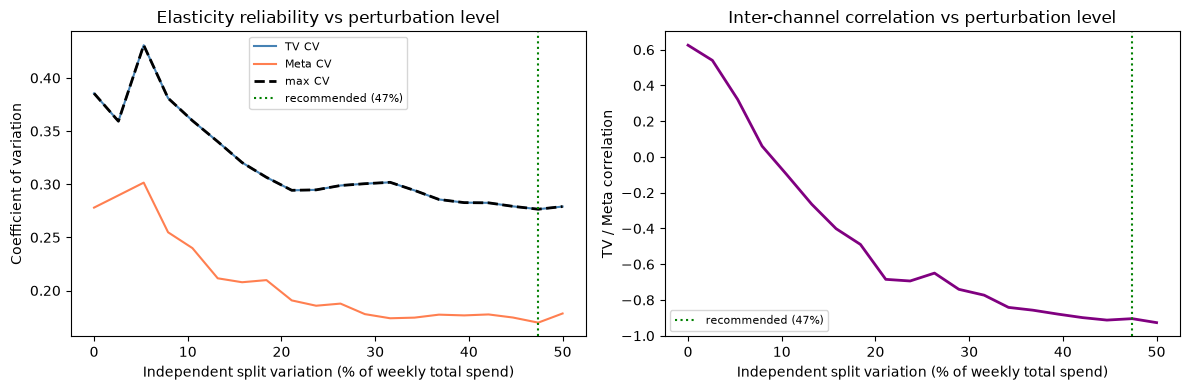

In [6]:
results = perturber.summary()
rec = perturber.recommend()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: CV vs perturbation %
ax = axes[0]
ax.plot(results["perturbation_pct"], results["tv_cv"], color="steelblue", label="TV CV")
ax.plot(results["perturbation_pct"], results["meta_cv"], color="coral", label="Meta CV")
ax.plot(results["perturbation_pct"], results["max_cv"], color="black", linewidth=2, linestyle="--", label="max CV")
ax.axvline(rec["perturbation_pct"], color="green", linestyle=":", linewidth=1.5, label=f"recommended ({rec['perturbation_pct']:.0f}%)")
ax.set_xlabel("Independent split variation (% of weekly total spend)")
ax.set_ylabel("Coefficient of variation")
ax.set_title("Elasticity reliability vs perturbation level")
ax.legend(fontsize=8)

# right: correlation vs perturbation %
ax = axes[1]
ax.plot(results["perturbation_pct"], results["actual_correlation"], color="purple", linewidth=2)
ax.axvline(rec["perturbation_pct"], color="green", linestyle=":", linewidth=1.5, label=f"recommended ({rec['perturbation_pct']:.0f}%)")
ax.set_xlabel("Independent split variation (% of weekly total spend)")
ax.set_ylabel("TV / Meta correlation")
ax.set_title("Inter-channel correlation vs perturbation level")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## The recommendation

The grid search returns the perturbation level that minimises max CV. Translated into practical terms: how much should you vary the TV/Meta split each week, independent of your campaign calendar?


In [7]:
rec = perturber.recommend()
mean_total = perturber.mean_weekly_total_

baseline_cv = perturber.summary()["max_cv"].iloc[0]
recommended_cv = rec["max_cv"]
cv_reduction = 100 * (baseline_cv - recommended_cv) / baseline_cv

print("Recommendation")
print("=" * 50)
print(f"Current TV/Meta correlation:   {spend['tv'].corr(spend['meta']):.2f}")
print(f"Recommended correlation target: {rec['actual_correlation']:.2f}")
print()
print(f"Weekly split variation to add: ±£{rec['perturbation_std']:,.0f}")
print(f"  (= {rec['perturbation_pct']:.0f}% of mean weekly total spend of £{mean_total:,.0f})")
print()
print(f"Max CV before: {baseline_cv:.3f}")
print(f"Max CV after:  {recommended_cv:.3f}")
print(f"Reduction:     {cv_reduction:.0f}%")


Recommendation
Current TV/Meta correlation:   0.63
Recommended correlation target: -0.90

Weekly split variation to add: ±£85,521
  (= 47% of mean weekly total spend of £180,545)

Max CV before: 0.386
Max CV after:  0.277
Reduction:     28%


## What perturbed spend looks like

It's useful to see what the recommended perturbation actually does to the spend data. The left scatter shows the original spend — the tight correlation between TV and Meta that creates the collinearity problem. The right scatter shows the spend after adding the recommended independent variation: the same total budget each week, but with the TV/Meta split varying independently.


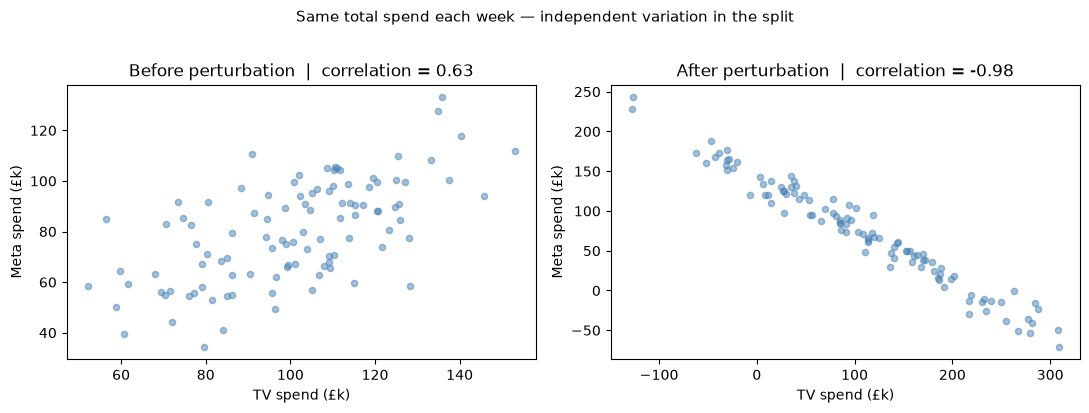

In [8]:
from how_wrong_is_your_mmm._perturber import _perturb_spend

perturbed_spend = _perturb_spend(spend, perturbation_std=rec["perturbation_std"], seed=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, df, title, corr in [
    (axes[0], spend, "Before perturbation", spend["tv"].corr(spend["meta"])),
    (axes[1], perturbed_spend, "After perturbation", perturbed_spend["tv"].corr(perturbed_spend["meta"])),
]:
    ax.scatter(df["tv"] / 1000, df["meta"] / 1000, alpha=0.5, s=20, color="steelblue")
    ax.set_xlabel("TV spend (£k)")
    ax.set_ylabel("Meta spend (£k)")
    ax.set_title(f"{title}  |  correlation = {corr:.2f}")

plt.suptitle("Same total spend each week — independent variation in the split", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## What to do with this

The recommendation above tells you how much independent variation to introduce into your TV/Meta budget split. In practice this means:

- In some weeks, deliberately shift budget toward TV (above what your campaign calendar would suggest)
- In other weeks, shift toward Meta
- The shifts should be independent of demand — not correlated with your overall budget level

After accumulating enough weeks of de-correlated data, your MMM will have the variation it needs to reliably distinguish TV and Meta effects. The `CollinearityWeighter` (next sprint) speeds this up further by upweighting the de-correlated periods in the model fit.
